In [16]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

# graph edges
EDGES = [
    (0,1), (0,2),                     # nose -> eyes
    (3,4),       # shoulders
    (3,5), (5,7), (7,9),       # left arm
    (4,6), (6,8), (8,10),      # right arm
    (13,14),               # hips
    (13,15), (15,17),         # left leg
    (14,16), (16,18),         # right leg
    (19,21), (20,22)                   # feet
]


In [17]:
import numpy as np

def normalize_pose(points):
    """
    points: np.array shape (23, 2)
    """

    pts = points.copy().astype(float)

    # centre
    left_hip = pts[11]
    right_hip = pts[12]
    root = (left_hip + right_hip) / 2
    pts -= root

    # scale
    left_sh = pts[3]
    right_sh = pts[4]
    shoulder_dist = np.linalg.norm(left_sh - right_sh)

    if shoulder_dist < 1e-6:
        shoulder_dist = 1e-6

    pts /= shoulder_dist

    # orientation
    dx = right_sh[0] - left_sh[0]
    dy = right_sh[1] - left_sh[1]
    theta = np.arctan2(dy, dx)

    R = np.array([
        [ np.cos(theta),  np.sin(theta)],
        [-np.sin(theta),  np.cos(theta)]
    ])

    pts = pts @ R.T

    return pts

def angle(a, b, c):
    v1 = a - b
    v2 = c - b
    cosang = np.dot(v1, v2) / (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-6)
    return np.arccos(np.clip(cosang, -1, 1))

In [19]:
def build_node_features(norm_pose):
    feats = []

    for i in range(len(norm_pose)):
        x, y = norm_pose[i]

        parent = None
        for (a,b) in EDGES:
            if b == i:
                parent = a
                break

        if parent is not None:
            rel = norm_pose[i] - norm_pose[parent]
            dist = np.linalg.norm(rel)
        else:
            rel = np.zeros(2)
            dist = 0.0

        ang = 0.0
        if i in [5,6,13,14]: 
            if i == 5: ang = angle(norm_pose[3], norm_pose[5], norm_pose[7])
            if i == 6: ang = angle(norm_pose[4], norm_pose[6], norm_pose[8])
            if i == 13: ang = angle(norm_pose[11], norm_pose[13], norm_pose[15])
            if i == 14: ang = angle(norm_pose[12], norm_pose[14], norm_pose[16])

        feats.append([x, y, rel[0], rel[1], dist, ang])

    return np.array(feats)

def build_edge_features(norm_pose):
    feats = []
    for (i,j) in EDGES:
        rel = norm_pose[j] - norm_pose[i]
        dist = np.linalg.norm(rel)
        feats.append([rel[0], rel[1], dist])
    return np.array(feats)


In [20]:
import matplotlib.pyplot as plt

def plot_pose(points, edges, title="Pose"):
    plt.figure(figsize=(5,5))
    for (i,j) in edges:
        if not np.any(np.isnan(points[i])) and not np.any(np.isnan(points[j])):
            plt.plot([points[i,0], points[j,0]],
                     [points[i,1], points[j,1]], 'k-', linewidth=2)

    plt.scatter(points[:,0], points[:,1], c='red', s=40)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('equal')
    plt.show()


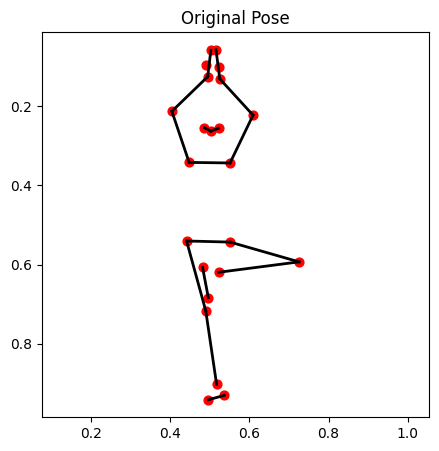

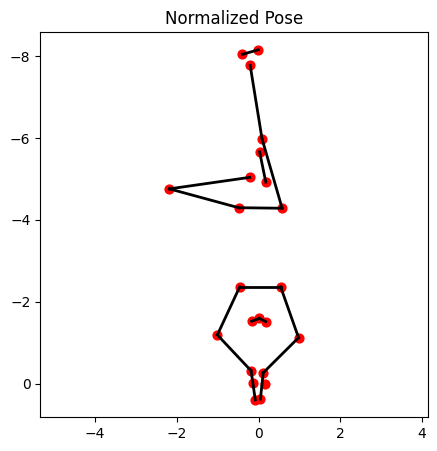

In [21]:

example_pose = np.array([
      [
        0.5024232633279483,
        0.2625
      ],
      [
        0.5218093699515347,
        0.25555555555555554
      ],
      [
        0.4862681744749596,
        0.25416666666666665
      ],
      [
        0.5508885298869144,
        0.34305555555555556
      ],
      [
        0.44749596122778673,
        0.3416666666666667
      ],
      [
        0.6090468497576736,
        0.2222222222222222
      ],
      [
        0.40387722132471726,
        0.2125
      ],
      [
        0.5250403877221325,
        0.13055555555555556
      ],
      [
        0.49434571890145396,
        0.125
      ],
      [
        0.5153473344103393,
        0.05694444444444444
      ],
      [
        0.5024232633279483,
        0.058333333333333334
      ],
      [
        0.5218093699515347,
        0.1
      ],
      [
        0.4911147011308562,
        0.09583333333333334
      ],
      [
        0.5508885298869144,
        0.5430555555555555
      ],
      [
        0.4410339256865913,
        0.5402777777777777
      ],
      [
        0.7253634894991923,
        0.5930555555555556
      ],
      [
        0.4894991922455573,
        0.7166666666666667
      ],
      [
        0.5218093699515347,
        0.6194444444444445
      ],
      [
        0.5169628432956381,
        0.9027777777777778
      ],
      [
        0.481421647819063,
        0.6069444444444444
      ],
      [
        0.5363489499192245,
        0.9305555555555556
      ],
      [
        0.49596122778675283,
        0.6833333333333333
      ],
      [
        0.49596122778675283,
        0.9416666666666667
      ]
    ])
  

# визуализация исходной позы
plot_pose(example_pose, EDGES, title="Original Pose")

# нормализация
norm_pose = normalize_pose(example_pose)

# визуализация нормализованной позы
plot_pose(norm_pose, EDGES, title="Normalized Pose")


In [57]:
import pandas as pd



def process_csv_for_gcn(csv_path, output_npz="gcn_dataset_test.npz"):
    df = pd.read_csv(csv_path)

    node_features = []
    edge_features = []
    labels = []

    for idx, row in df.iterrows():
        pts = []
        for name in KEYPOINT_NAMES:
            pts.append([row[f"{name}_x"], row[f"{name}_y"]])
        pts = np.array(pts, dtype=float)

        norm_pts = normalize_pose(pts)

        nf = build_node_features(norm_pts)
        ef = build_edge_features(norm_pts)

        node_features.append(nf)
        edge_features.append(ef)
        labels.append(row["class"])

    np.savez(output_npz,
             node_features=np.array(node_features),
             edge_features=np.array(edge_features),
             labels=np.array(labels),
             edges=np.array(EDGES))

    print(f"Saved GCN dataset to {output_npz}")

    return node_features, edge_features, labels


In [58]:
process_csv_for_gcn(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\test_data.csv")

Saved GCN dataset to gcn_dataset_test.npz


([array([[-5.56983632e-02,  3.17430653e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [-1.72846429e-01,  3.31736023e+00, -1.17148065e-01,
           1.43053695e-01,  1.84900051e-01,  0.00000000e+00],
         [ 5.43692648e-02,  3.32228128e+00,  1.10067628e-01,
           1.47974750e-01,  1.84421824e-01,  0.00000000e+00],
         [-5.37842226e-01,  2.36148657e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 4.62157774e-01,  2.36148657e+00,  1.00000000e+00,
          -4.44089210e-16,  1.00000000e+00,  0.00000000e+00],
         [-4.25080626e-01,  1.25885064e+00,  1.12761601e-01,
          -1.10263593e+00,  1.10838675e+00,  3.05207320e+00],
         [ 3.88124032e-01,  1.23792788e+00, -7.40337414e-02,
          -1.12355869e+00,  1.12599517e+00,  3.02665373e+00],
         [-2.44494087e-01,  3.26997086e-01,  1.80586539e-01,
          -9.31853550e-01,  9.49190463e-01,  0.00000000e+00],
         [ 2.073

In [37]:
data = np.load("gcn_dataset_valid.npz", allow_pickle=True)

node_features = data["node_features"]
edge_features = data["edge_features"]
edges = data["edges"]
labels = data["labels"]


In [38]:
print(node_features.shape)
print(edge_features.shape)
print(edges.shape)
print(labels.shape)


(203, 23, 6)
(203, 16, 3)
(16, 2)
(203,)


In [59]:
train = np.load("gcn_dataset_train.npz", allow_pickle=True)
valid = np.load("gcn_dataset_valid.npz", allow_pickle=True)
test  = np.load("gcn_dataset_test.npz", allow_pickle=True)


labels = train["labels"]

print("Уникальные классы:", np.unique(labels))
print("Количество классов:", len(np.unique(labels)))


Уникальные классы: [0 1 2 3 4 5 6]
Количество классов: 7


In [60]:
from torch_geometric.data import Dataset
from torch_geometric.data import Data
import torch

class YogaGCNDataset(Dataset):
    def __init__(self, npz_path):
        super().__init__()
        data = np.load(npz_path, allow_pickle=True)
        self.node_features = data["node_features"]
        self.edge_features = data["edge_features"]
        self.edges = torch.tensor(data["edges"], dtype=torch.long).t().contiguous()
        self.labels = data["labels"]

    def len(self):
        return len(self.labels)

    def get(self, idx):
        x = torch.tensor(self.node_features[idx], dtype=torch.float)
        edge_attr = torch.tensor(self.edge_features[idx], dtype=torch.float)
        y = torch.tensor(self.labels[idx], dtype=torch.long)

        return Data(
            x=x,
            edge_index=self.edges,
            edge_attr=edge_attr,
            y=y
        )

from torch_geometric.loader import DataLoader

train_ds = YogaGCNDataset("gcn_dataset_train.npz")
valid_ds = YogaGCNDataset("gcn_dataset_valid.npz")
test_ds  = YogaGCNDataset("gcn_dataset_test.npz")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F


class YogaGCN(nn.Module):
    def __init__(self, in_channels, edge_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 64)
        self.conv2 = GCNConv(64, 64)
        self.lin1 = nn.Linear(64, 32)
        self.lin2 = nn.Linear(32, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        x = self.lin1(x).relu()
        return self.lin2(x)


model = YogaGCN(in_channels=node_features.shape[-1],
                edge_dim=edge_features.shape[-1],
                num_classes=len(np.unique(labels)))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()

    print("epoch", epoch, "loss", loss.item())


epoch 0 loss nan
epoch 1 loss nan
epoch 2 loss nan
epoch 3 loss nan
epoch 4 loss nan
epoch 5 loss nan
epoch 6 loss nan
epoch 7 loss nan
epoch 8 loss nan
epoch 9 loss nan


In [62]:
model.eval()
correct = 0

for batch in test_loader:
    out = model(batch.x, batch.edge_index, batch.batch)
    pred = out.argmax(dim=1)
    correct += (pred == batch.y).sum().item()

print("Accuracy:", correct / len(test_ds))


Accuracy: 0.17647058823529413
